In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
import re


In [12]:
ruta=''

In [13]:
df = pd.read_csv(ruta+'proveedores2016_2022_nuevas_var_disc_ipc.csv', sep='|')

### armar dataset con las variables categóricas

In [14]:
df_cat=df[['Estado','TipoSocietario','provincia','dmonto_total_adjudicado','dcant_procesos_adjudicado','dtotal_articulos_provee']]

### agregar variables dicotómicas

In [ ]:
df_cat['tiene_socios'] = (df['cant_socios'] > 0).astype(int)
df_cat['tiene_antecedentes'] = ((df['cant_apercibimientos'] > 0) & (df['cant_suspensiones'] > 0) & (df['cant_antecedentes'] > 0)).astype(int)
df_cat['tiene_representante'] = ((df['cant_Apoderado'] > 0) & (df['cant_representante'] > 0)).astype(int)

In [6]:
df_cat

,Estado,TipoSocietario,provincia,dmonto_total_adjudicado,dcant_procesos_adjudicado,dtotal_articulos_provee,tiene_socios,tiene_antecedentes,tiene_representante
0,Inscripto,Persona Física,Chubut,"(9424898.401, 13557176.81]","(39.0, 1214.0]","(58.0, 97.6]",0,0,0
1,Desactualizado Por Documentos Vencidos,Sociedades De Hecho,Ciudad Autónoma de Buenos Aires,"(4727330.113, 6702697.888]","(6.0, 8.0]","(161.0, 345.0]",1,0,0
2,Inscripto,Sociedad Responsabilidad Limitada,Ciudad Autónoma de Buenos Aires,"(6702697.888, 9424898.401]","(19.0, 39.0]","(97.6, 161.0]",1,1,1
3,Inscripto,Sociedad Anónima,Ciudad Autónoma de Buenos Aires,"(46718747.516, 89439449.702]","(39.0, 1214.0]","(58.0, 97.6]",1,0,0
4,Inscripto,Sociedad Responsabilidad Limitada,Buenos Aires,"(4727330.113, 6702697.888]","(0.999, 2.0]","(29.0, 40.0]",1,0,0
...,...,...,...,...,...,...,...,...,...
10071,Inscripto,Persona Física,Buenos Aires,"(4727330.113, 6702697.888]","(0.999, 2.0]","(0.999, 2.0]",0,0,0
10072,Inscripto,Sociedad Anónima,Ciudad Autónoma de Buenos Aires,"(13557176.81, 19975532.58]","(0.999, 2.0]","(4.0, 6.0]",1,0,1
10073,Inscripto,Sociedad Anónima,Ciudad Autónoma de Buenos Aires,"(9424898.401, 13557176.81]","(0.999, 2.0]","(0.999, 2.0]",1,0,0
10074,Inscripto,Otras Formas Societarias,Ciudad Autónoma de Buenos Aires,"(104767.373, 224078.198]","(0.999, 2.0]","(15.0, 21.0]",1,0,0


### Se realiza la imputación de los datos

In [ ]:
#En este caso se imputa el valor nulo con 0 porque se interpreta el nulo como que no tiene procesos adjudicados.
df_cat['Estado'] = df_cat['Estado'].fillna('sin datos')
df_cat['TipoSocietario'] = df_cat['TipoSocietario'].fillna('sin datos')
df_cat['dmonto_total_adjudicado'] = df_cat['dmonto_total_adjudicado'].fillna('sin datos')
df_cat['dcant_procesos_adjudicado'] = df_cat['dcant_procesos_adjudicado'].fillna('sin datos')
df_cat['dtotal_articulos_provee'] = df_cat['dtotal_articulos_provee'].fillna('sin datos')

In [16]:
#ver el % de nulos por variables
total_filas = len(df)

# Calcular cantidad y porcentaje de nulos por variable
nulos_por_variable = df_cat.isnull().sum().reset_index()
nulos_por_variable.columns = ['Variable', 'Cantidad de Nulos']
nulos_por_variable['Porcentaje de Nulos (%)'] = (nulos_por_variable['Cantidad de Nulos'] / total_filas) * 100

#pd.set_option('display.max_rows', None)
# Mostrar la tabla
nulos_por_variable

,Variable,Cantidad de Nulos,Porcentaje de Nulos (%)
0,Estado,99,0.982533
1,TipoSocietario,99,0.982533
2,provincia,0,0.000000
3,dmonto_total_adjudicado,51,0.506153
4,dcant_procesos_adjudicado,51,0.506153
5,dtotal_articulos_provee,99,0.982533
6,tiene_socios,0,0.000000
7,tiene_antecedentes,0,0.000000
8,tiene_representante,0,0.000000


In [17]:
#Label Encoding
# Aplicar Label Encoding a las columnas categóricas
encoder = LabelEncoder()

df_cat_encoding = df_cat.copy()
# Convertir todas las columnas categóricas
for column in df_cat_encoding.columns:
    df_cat_encoding[column] = encoder.fit_transform(df_cat_encoding[column])

In [18]:
df_cat_encoding

,Estado,TipoSocietario,provincia,dmonto_total_adjudicado,dcant_procesos_adjudicado,dtotal_articulos_provee,tiene_socios,tiene_antecedentes,tiene_representante
0,7,3,4,19,5,11,0,0,0
1,3,8,5,14,8,3,1,0,0
2,7,7,5,16,2,14,1,1,1
3,7,6,5,13,5,11,1,0,0
4,7,7,1,14,0,6,1,0,0
...,...,...,...,...,...,...,...,...,...
10071,7,3,1,14,0,0,0,0,0
10072,7,6,5,3,0,9,1,0,1
10073,7,6,5,19,0,0,1,0,0
10074,7,2,5,1,0,2,1,0,0


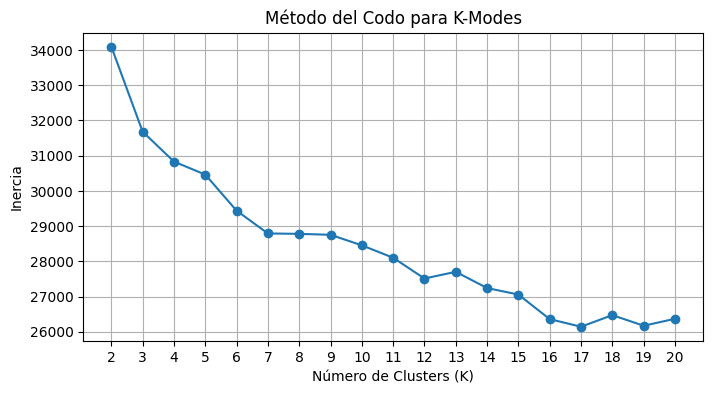

In [11]:
# Lista para almacenar las inercia (coste) para cada número de clusters
inertia = []

# Evaluar para valores de K entre 2 y 10 (o más si lo deseas)
for k in range(2, 21):
    km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=10)
    km.fit(df_cat_encoding)  # Ajustar el modelo
    inertia.append(km.cost_)

# Graficar el método del codo
k_values = list(range(2, 21))

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o')
plt.xticks(k_values)  # Fuerza que se muestren todos los valores del eje X
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para K-Modes")
plt.grid(True)
plt.show()

#### silhouette

In [19]:
#Determina el número de clusters (K) 
# Lista para almacenar los scores
silhouette_scores = []
cluster_counts = {}
rango_k = range(2, 21) 
# Evaluar para valores de K entre 2 y 20
for k in rango_k :
    km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=10)
    clusters = km.fit_predict(df_cat_encoding)
    score = silhouette_score(df_cat_encoding, clusters, metric='hamming')  # Utilizando distancia de Hamming
    silhouette_scores.append(score)

    
    # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    #etiquetas = kmeans.fit_predict(df_sink1_normalizado)
    #score = silhouette_score(df_sink1_normalizado, etiquetas)
    #silhouette_scores.append(score)

    # Agregar la columna del clúster al DataFrame
    df[f'cluster_k_{k}'] = clusters
    
    # Contar los clusters
    cluster_counts[k] = df[f'cluster_k_{k}'].value_counts().to_dict()
    
    print(f"K={k}, Silhouette Score={score:.4f}")
    print(df[f'cluster_k_{k}'].value_counts())

   
# Imprimir el valor de Silhouette Score para cada K
for k, score in zip(range(2, 11), silhouette_scores):
    print(f'K={k}, Silhouette Score={score}')

    # Crear la tabla de resultados
resultados = []
for k, clusters in cluster_counts.items():
    for cluster, count in clusters.items():
        resultados.append({'K': k, 'Cluster': cluster, 'Count': count, 'Silhouette Score': silhouette_scores[k - 2]})

# Convertir a DataFrame
tabla_resultados = pd.DataFrame(resultados)

# Mostrar la tabla de puntajes
resultado_silhouette = pd.DataFrame({'K': rango_k , 'Silhouette Score': silhouette_scores})
print(resultado_silhouette)

# Mostrar la tabla final
tabla_resultados = tabla_resultados.sort_values(['K', 'Cluster']).reset_index(drop=True)
print(tabla_resultados)

 

K=2, Silhouette Score=0.2312
cluster_k_2
1    5410
0    4666
Name: count, dtype: int64
K=3, Silhouette Score=0.2203
cluster_k_3
1    3952
0    3874
2    2250
Name: count, dtype: int64
K=4, Silhouette Score=0.2223
cluster_k_4
1    3891
0    3190
2    2674
3     321
Name: count, dtype: int64
K=5, Silhouette Score=0.0981
cluster_k_5
0    3585
1    3384
2    1304
3    1230
4     573
Name: count, dtype: int64
K=6, Silhouette Score=0.0856
cluster_k_6
0    3139
3    1902
1    1746
4    1210
2    1201
5     878
Name: count, dtype: int64
K=7, Silhouette Score=0.0758
cluster_k_7
0    2854
1    2431
3    1655
2    1047
6     917
5     615
4     557
Name: count, dtype: int64
K=8, Silhouette Score=0.0628
cluster_k_8
0    3039
1    2577
2    1762
6     768
7     691
5     614
4     324
3     301
Name: count, dtype: int64
K=9, Silhouette Score=0.0842
cluster_k_9
0    2819
5    2790
1    1525
7     678
2     653
3     569
8     525
6     365
4     152
Name: count, dtype: int64
K=10, Silhouette Score=0

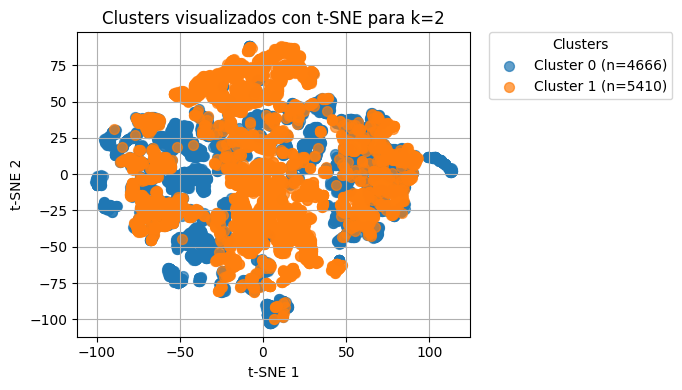

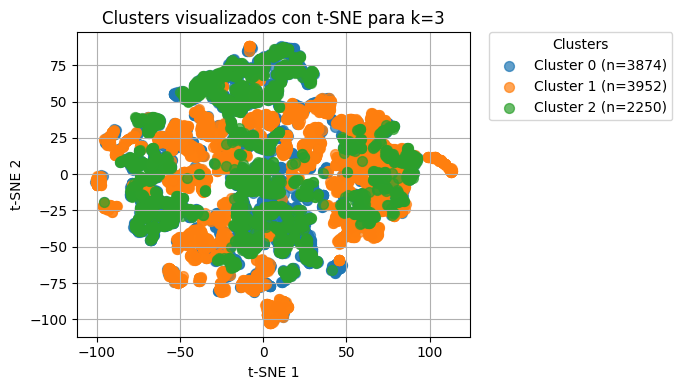

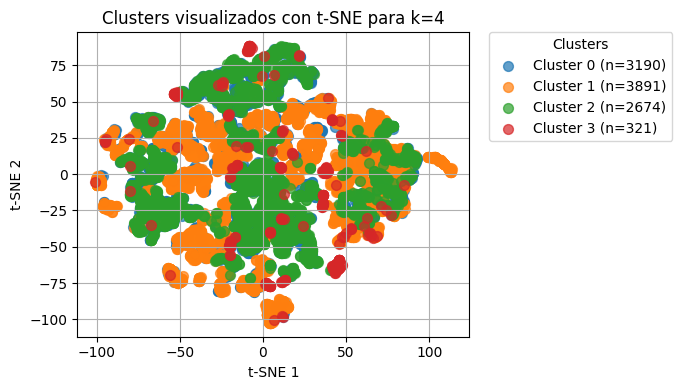

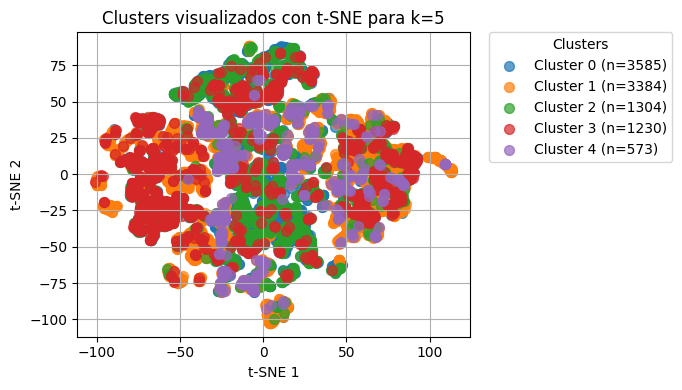

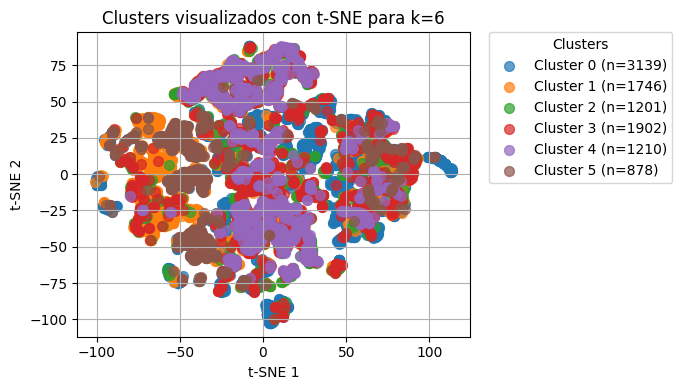

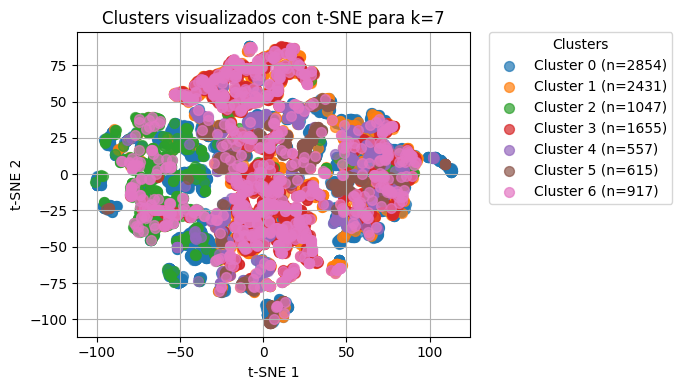

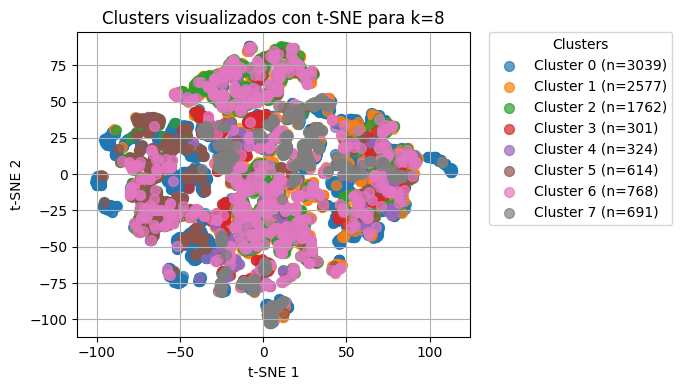

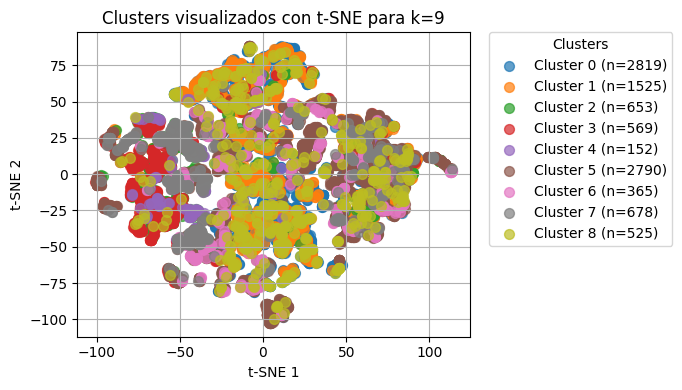

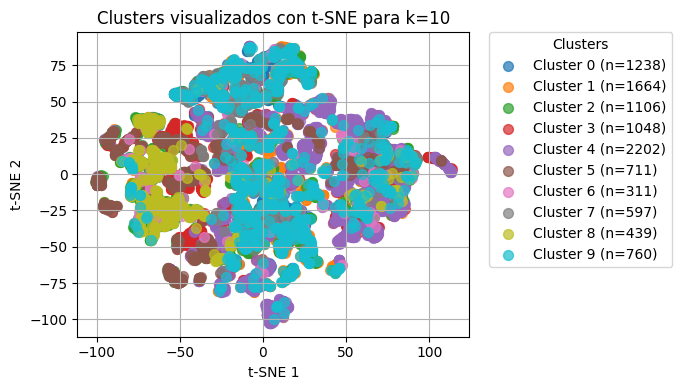

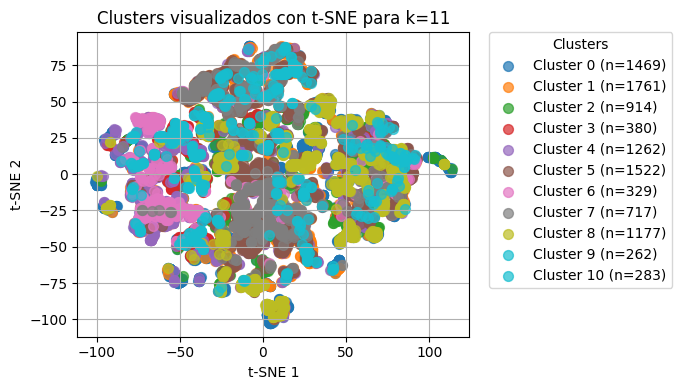

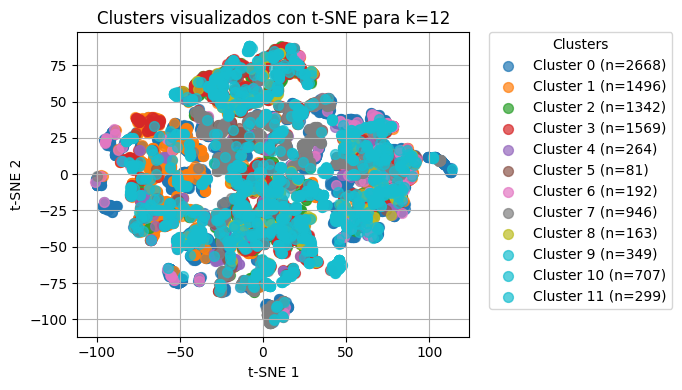

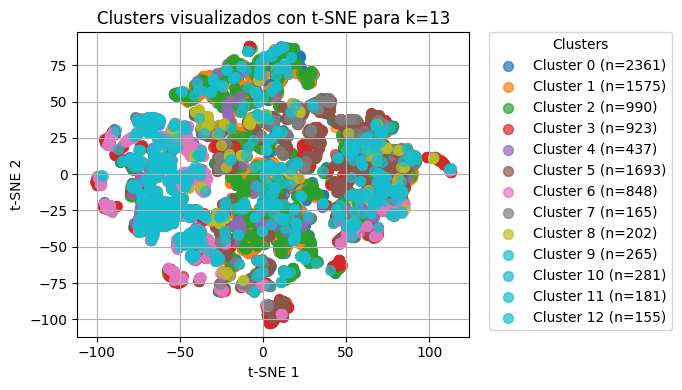

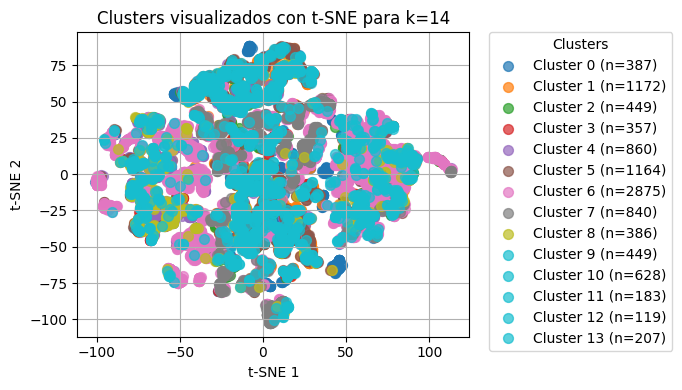

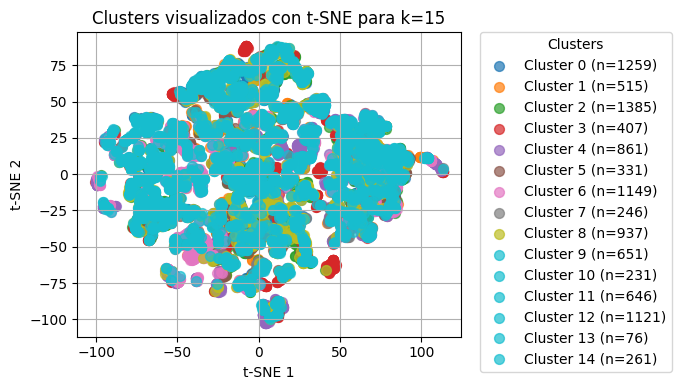

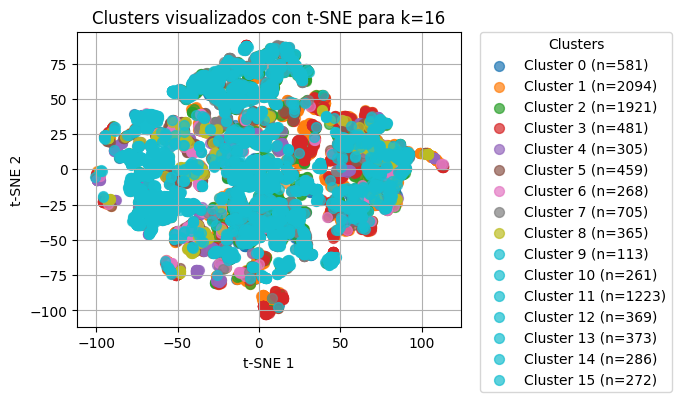

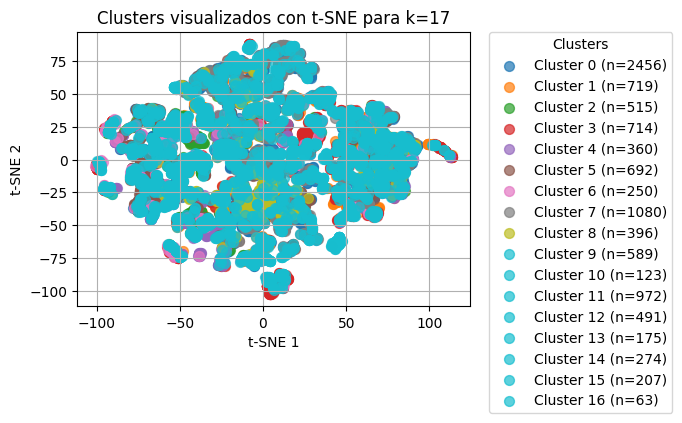

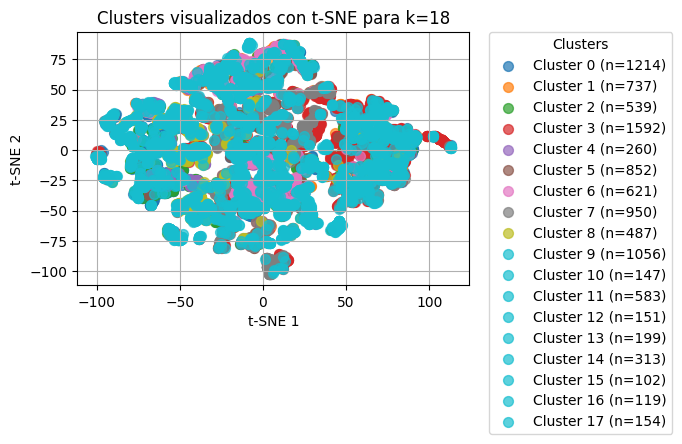

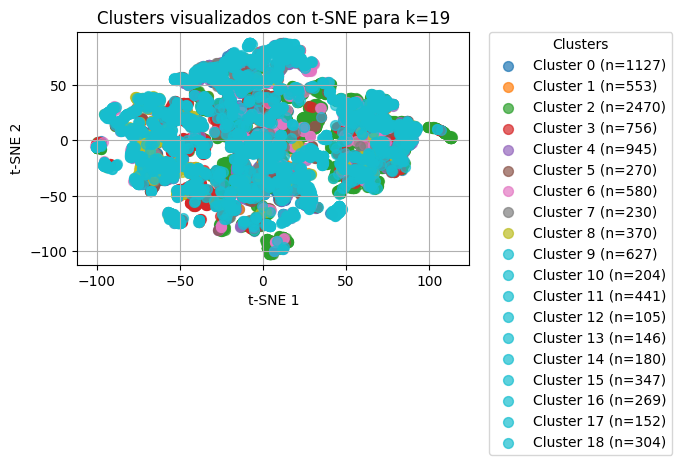

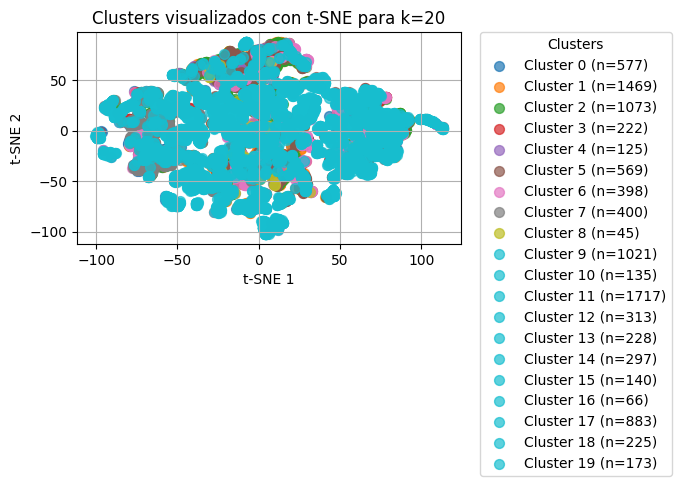

In [13]:
# Reducimos dimensiones con t-SNE (esto puede tomar tiempo)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df_cat_encoding)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20]
#k_values = [2]
for k in k_values:
    km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=10)
    labels = km.fit_predict(df_cat_encoding)
    #labels = kmeans.fit_predict(df_cat_encoding)
    
    plt.figure(figsize=(7,4))  # un poco más ancho para dar espacio a la leyenda
    cmap = plt.get_cmap('tab10')
    
    for cluster_id in range(k):
        idx = labels == cluster_id
        count = idx.sum()
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    color=cmap(cluster_id),
                    label=f'Cluster {cluster_id} (n={count})',
                    alpha=0.7,
                    s=50)
    
    plt.title(f'Clusters visualizados con t-SNE para k={k}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)

    # Leyenda fuera del gráfico
    plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
   
    
    plt.tight_layout()  # Ajusta el espacio para evitar que se corte la leyenda
    plt.savefig(ruta+f'clusters_tsne_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [20]:
tabla_resultados.to_csv(ruta+'resultado_cluster_kmode2.csv', sep='|', encoding='utf-8', decimal=',')

In [15]:
df.to_csv(ruta+'df_cat_cluster_kmode.csv', sep='|', encoding='utf-8', decimal=',')

In [13]:
df

,Unnamed: 0,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,...,cluster_k_11,cluster_k_12,cluster_k_13,cluster_k_14,cluster_k_15,cluster_k_16,cluster_k_17,cluster_k_18,cluster_k_19,cluster_k_20
0,0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,9,0,7,6,1,1,1,3,2,9
1,1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,3,2,0,2,0,2,0,5,0,12
2,2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...",...,1,2,1,1,5,0,0,1,4,2
3,3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...",...,4,3,0,4,12,10,7,6,1,1
4,4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...",...,4,1,1,9,2,13,0,0,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0,0,6,6,6,1,11,11,11,11
10072,10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...",...,1,10,2,1,8,7,9,2,15,1
10073,10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,1,3,0,5,12,11,7,9,9,1
10074,10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,5,2,11,5,2,2,0,5,13,1


### Gráfico de barras superpuestas

In [9]:
# Conteos en porcentaje para el original
def graficar_barras_comparacion(df, columna, condicion_filtrado, titulo, grupo):
    """
    Grafica la distribución porcentual de una variable categórica en dos universos:
    - Todo el DataFrame
    - Solo los casos que cumplen una condición dada
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos.
    columna : str
        Nombre de la columna categórica a graficar.
    titulo : str
        Título para el gráfico.
   
    """
    
    # Conteo porcentual en el DataFrame original
    conteo_original = df[columna].value_counts(normalize=True) * 100
    
    # Filtrar según la condición
    df_filtrado = df[condicion_filtrado(df)]
    conteo_filtrado = df_filtrado[columna].value_counts(normalize=True) * 100
    
    # Unificar índices para que ambas series tengan las mismas categorías
    categorias = conteo_original.index.union(conteo_filtrado.index)
    conteo_original = conteo_original.reindex(categorias, fill_value=0)
    conteo_filtrado = conteo_filtrado.reindex(categorias, fill_value=0)
    
    # Crear gráfico
    plt.figure(figsize=(6, 4))
    plt.bar(conteo_original.index, conteo_original.values, color='skyblue', alpha=0.6, label='Universo')
    plt.bar(conteo_filtrado.index, conteo_filtrado.values, facecolor='none', edgecolor='red', linewidth=2, label=grupo)
    
    plt.title(titulo, fontsize=11)
    plt.xlabel(columna, fontsize=9)
    plt.ylabel('Porcentaje de Casos', fontsize=9)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=9)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

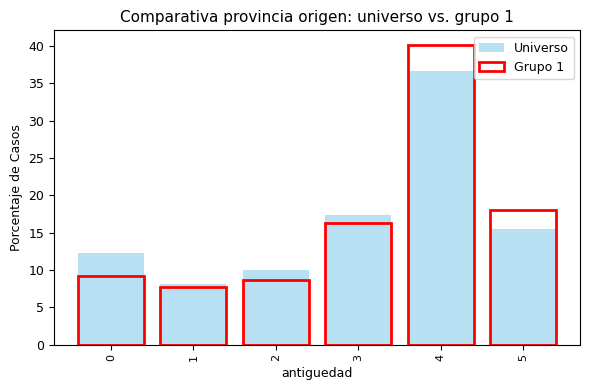

In [88]:
graficar_barras_comparacion(
    df=df,
    columna='antiguedad',
    condicion_filtrado=lambda df: df['cluster_k_4'] == 0,
    titulo='Comparativa provincia origen: universo vs. grupo 1',
    grupo='Grupo 1'
)

In [42]:
df['provincia'] = df['provincia'].str.replace('Ciudad Autónoma de Buenos Aires', 'CABA', regex=False)

In [22]:
# Convertir la columna 'numero' a string
df['anio_preinscripcion'] = df['anio_preinscripcion'].astype(str)

In [53]:
# Acortar los nombres 
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Física Extranjero No Residente', 'PF Extranjero No Residente', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Jurídica Extranjero Sin Sucursal', 'PJ Extranjero Sin Sucursal', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Sociedad Responsabilidad Limitada', 'S.R.L', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Talleres protegidos de Producción', 'Talleres protegidos', regex=False)

In [48]:
df['Estado'] = df['Estado'].str.replace('Desactualizado Por Documentos Vencidos', 'Desactualizado doc. vencidos', regex=False)
df['Estado'] = df['Estado'].str.replace('Desactualizado Por Mantencion Formulario', 'Desactualizado mantención', regex=False)

In [11]:
def limpiar_rango(val):
    # Reemplaza todos los números con punto decimal por la parte antes del punto
    matches = re.findall(r'\d+,\d+', val)
  #  return re.sub(r'(\d+)\,\d+', r'\1', val)
    for match in matches:
        # Parte entera antes de la coma
        entero = match.split(',')[0]
        # Agrega punto como separador de miles
        entero_formateado = f"{int(entero):,}".replace(",", ".")
        # Reemplaza el número original con el formateado
        val = val.replace(match, entero_formateado)
    return val


In [12]:

df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.replace('.', ',', regex=False)
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.replace('-0.001', '0', regex=False)
# Aplica la función a la columna deseada
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].astype(str).apply(limpiar_rango)
#df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.split(',').str[0]


In [32]:
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.replace(',', '-', regex=False)

### Crear perfiles de los grupos

In [12]:
df_perfil = df[['CUIT','Nombre','FechaPreinscripcion','Estado','TipoSocietario','periodo_preinscripcion','anio_preinscripcion','cant_procesos_adjudicado','monto_total_adjudicado','antiguedad','provincia','cant_socios','cant_apercibimientos','cant_suspensiones','cant_antecedentes','cant_Apoderado','cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite','total_articulos_provee','dmonto_total_adjudicado','dcant_procesos_adjudicado','dtotal_articulos_provee','cluster_k_4']]

In [20]:
grupo1 = df_perfil[df_perfil['cluster_k_4'] == 0].copy()
#grupo1


In [14]:
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 1", explorative=True)
profile.to_file(ruta+"informe_perfil_kmodes_g1.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:02,  8.64it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 54.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
# Crear el perfil grupo 2

grupo2 = df_perfil[df_perfil['cluster_k_4'] == 1].copy()
profile = ProfileReport(grupo2, title="Informe de análisis exploratorio kmodes grupo 2", explorative=True)
profile.to_file(ruta+"informe_perfil_kmodes_g2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:05,  4.48it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 73.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
# Crear el perfil grupo 3

grupo2 = df_perfil[df_perfil['cluster_k_4'] == 2].copy()
profile = ProfileReport(grupo2, title="Informe de análisis exploratorio kmodes grupo 3", explorative=True)
profile.to_file(ruta+"informe_perfil_kmodes_g3html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:02, 11.98it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 87.19it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\profile_report.py:386: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
grupo2 = df_perfil[df_perfil['cluster_k_4'] == 3].copy()
profile = ProfileReport(grupo2, title="Informe de análisis exploratorio kmodes grupo 4", explorative=True)
profile.to_file(ruta+"informe_perfil_kmodes_g4html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:02,  9.18it/s]
100%|█████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 107.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\profile_report.py:386: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
profile = ProfileReport(df_perfil, title="Informe de análisis exploratorio proveedores", explorative=True)
profile.to_file(ruta+"informe_perfil_proveedores.html")

C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:09,  2.67it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 34.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]